# **Riconoscimento di animali per auto a guida autonoma**

## **Importazione moduli python utili**

In [1]:
#say no to warnings!
import warnings
warnings.filterwarnings("ignore")
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

import tensorflow as tf
from tensorflow.keras import layers, models, datasets
from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Input, Conv2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import MaxPool2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.backend import clear_session
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, precision_score
from tensorflow.keras.backend import clear_session

## **Import database CIFAR-10**

In [2]:

cifar10 = tf.keras.datasets.cifar10

## **Definizione test set I/O e train set I/O**

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
#check dimensione
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


## **Adimensionalizzazione e riduzione di dimensione**

In [4]:
x_train,x_test = x_train/255.0,x_test/255.0
# riduzione dimensione vettori y_
y_train,y_test = y_train.flatten(),y_test.flatten()

In [5]:
#check dimensione
y_train.shape
#print vettore
y_train

array([6, 9, 9, ..., 9, 1, 1], shape=(50000,), dtype=uint8)

## **Riduzione delle 10 categorie ufficiali del dataset alle 2 richieste**
### *Animali e Veicoli*

In [6]:
def map_to_binary(labels):
    animals = [2, 3, 4, 5, 6, 7]
    vehicles = [0, 1, 8, 9]
    mask_animals = np.isin(labels, animals)
    mask_vehicles = np.isin(labels, vehicles)
    labels[mask_animals] = 0
    labels[mask_vehicles] = 1
    return labels

In [7]:
y_train_bin = map_to_binary(y_train)
y_test_bin = map_to_binary(y_test)

# check dimensione
print(y_train_bin.shape)
print(y_test_bin.shape)
print(x_train.shape)
print(x_test.shape)

(50000,)
(10000,)
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [8]:
#check valori
y_train_bin

array([0, 1, 1, ..., 1, 1, 1], shape=(50000,), dtype=uint8)

In [9]:
#check dimensione
print(x_train.shape)
print(x_test.shape)
print(y_train_bin.shape)
print(y_test_bin.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000,)
(10000,)


## **Definizione della rete CNN**
### *Disposizione dei layer per il riconoscimento e la classificazione di immagini*

L'impronta è quella della rete AlexNet.
Quindi i layer convolutivi e quelli di pooling sono stati disposti secondo le istruzioni previste tale da non rompere la dimensionalità in output della rete mantenendo l'orchestrazione delle dimensioni dei vettori x ed y

Il layer denso finale è stato imposto pari a 2 ovvero pari al numero delle categorie "Animali" e "Veicoli" richieste ne consegue la selezione della funzione di attivazione "Softmax" e della loss function "sparse categorical crossentropy"

Da notare che nonostante il ridottissimo numero di parametri della rete, il risultato finale è comunque molto ottimizzato

In [10]:
#pulizia della memoria
clear_session()

#definizione del modello sequenziale
cnn = models.Sequential([
    InputLayer(input_shape = (32,32,3)),

    # 1 blocco convoluzionale
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),

    # 2 blocco convoluzionale
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),

    # 3 blocco convoluzionale
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),


    # Strati densi per la classificazione
    #GlobalAveragePooling2D(),
    Flatten(),
    Dropout(0.2),
    Dense(1024, activation='relu'),
    Dropout(0.2),
    Dense(2, activation='softmax') # Sigmoid per classificazione binaria
])

#plot delle caratteristiche e dei parametri della rete
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,266 (2.19 MB)

 Trainable params: 574,882 (2.19 MB)

 Non-trainable params: 384 (1.50 KB)

## **Compile - definizione optimizer, loss function e metriche**
### **Stochastic Gradient Descend & Sparse categorical crossentropy**
*definizione delle funzioni per l'aggiornamento dei pesi della rete neurale al fine di minimizzare la funzione di perdita*


In [11]:
cnn.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
batch_size = 32
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(
  width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)

train_generator = data_generator.flow(x_train, y_train_bin, batch_size)
steps_per_epoch = x_train.shape[0] // batch_size

In [13]:
cnn.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4000 - loss: 0.6967


[0.696685254573822, 0.4000000059604645]

### **Callbacks** <br>
### *migliorare il reindimento della rete*

**Early Stopping** <br> è una forma di regolarizzazione basata sulla performance sul validation set.

**monitor**='val_loss': Il "radar" osserva la perdita sul set di validazione.

**patience**=10: Il modello ha una "tolleranza" di 10 epoche. Se la val_loss non diminuisce per 10 epoche consecutive, l'addestramento viene interrotto.

**restore_best_weights**=True: Al termine, il codice ripristina automaticamente i pesi del modello corrispondenti all'epoca con la val_loss minima, scartando i pesi peggiori delle ultime 10 epoche "inutili".

**ReduceLROnPlateau** <br>
Questa funzione ottimizza la discesa del gradiente. Quando il modello smette di migliorare, è probabile che il "passo" (Learning Rate) sia troppo grande per scendere ulteriormente nel minimo della funzione di costo.

**factor**=0.2: Riduce il Learning Rate dell'80% (moltiplica per 0.2).

**patience**=5: È più reattivo dell'EarlyStopping (interviene dopo solo 5 epoche di stallo).

**min_lr**=0.0001: Imposta un "pavimento" sotto il quale il tasso di apprendimento non può scendere, per evitare che diventi infinitesimale.

In [14]:
print("Inizio addestramento (50 epoche)...")
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

history = cnn.fit(train_generator, validation_data=(x_test, y_test_bin),
               steps_per_epoch=steps_per_epoch, epochs=50, callbacks=[early_stopping, reduce_lr])

Inizio addestramento (50 epoche)...
Epoch 1/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 51s 32ms/step - accuracy: 0.8673 - loss: 0.3216 - val_accuracy: 0.8506 - val_loss: 0.3370 - learning_rate: 0.0100
Epoch 2/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9062 - loss: 0.3067 - val_accuracy: 0.8531 - val_loss: 0.3294 - learning_rate: 0.0100
Epoch 3/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.9017 - loss: 0.2438 - val_accuracy: 0.9201 - val_loss: 0.1984 - learning_rate: 0.0100
Epoch 4/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9375 - loss: 0.1601 - val_accuracy: 0.9197 - val_loss: 0.1997 - learning_rate: 0.0100
Epoch 5/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.9147 - loss: 0.2161 - val_accuracy: 0.9166 - val_loss: 0.2079 - learning_rate: 0.0100
Epoch 6/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9062 - loss: 0.1902 - val_accuracy: 0.9013 - val_loss: 0.2418 - learning_rate: 0.0100
Epoch 7/50
1562/1562 ━━━━━━━━━━━━━

## **Valutazione del rendimento della CNN**
### *Loss & Accuracy*
Si è ottenuto un accuracy del 96% con una loss di 0.1, quindi si ritiene di aver condotto un buon training della rete

In [18]:
cnn.evaluate(x_test, y_test_bin)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9614 - loss: 0.1018


[0.10184474289417267, 0.9613999724388123]

## **Plot**
### *visualizzare il rendimento della CNN*
Gli andmaneti dimostraano una accuracy crescente o che oscilla intorno ad un valore medio crescente e una lo decrescente con lo stesso andamento. Tale andamento è stato imposto tramite le callbacks

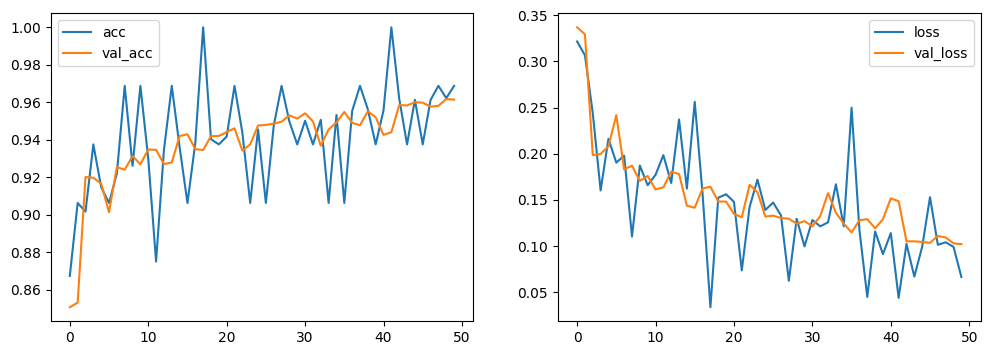

In [16]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()

## **Calcolo della precisione del modello**
### *Classification Report*

In [144]:
y_pred = (cnn.predict(x_test) > 0.5).astype("int32")
y_preds = np.array([0,1])[np.argmax(y_pred,axis=1)]
precision = precision_score(y_test_bin, y_preds)
print('-'*100)
print(f"Precisione (Qualità predizioni positive): {precision*100:.2f}%")
print('-'*100)
print("\nReport di Classificazione:")
print('-'*100)
print(classification_report(y_test_bin, y_preds, target_names=['Animale', 'Veicolo']))
print('-'*100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
----------------------------------------------------------------------------------------------------
Precisione (Qualità predizioni positive): 93.63%
----------------------------------------------------------------------------------------------------

Report di Classificazione:
              precision    recall  f1-score   support

     Animale       0.98      0.96      0.97      6000
     Veicolo       0.94      0.97      0.95      4000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



## **Analisi delle predizione e critica del risultato**

### Conversione del dato di previsione da modello addestrato da binario a stringa

In [107]:
y_pred_str = np.where(y_preds == 0, 'Animale', 'Veicolo')
len(y_pred_str)

10000

### Conversione del dato di test del dataset da binario a stringa

In [108]:
y_test_bin_str = np.where(y_test_bin == 0, 'Animale', 'Veicolo')

### Preparazione del dato per il plot

In [109]:
from tensorflow.keras.preprocessing.image import \
    ImageDataGenerator,load_img,array_to_img,img_to_array

### Confronto vettoriale tra dataset di test e risultato di previsione
*L'obbiettivo è quello di ottenere il numero di elementi errati in previsione che quindi si troveranno allo stesso indice ma con stringa diversa*

In [143]:
err = (y_pred_str == y_test_bin_str)
index = np.where(~err)

print('-'*100)
print('predizioni errate:', len(index[0]))
perc = 100 *(len(index[0])/len(y_pred_str))
print('percentuale su tot:', round(perc,2),'%')
print('-'*100)
print('predizioni corrette:', 10000-386)
print('percentuale su tot:', round(100-perc,2),'%')
print('-'*100)

----------------------------------------------------------------------------------------------------
predizioni errate: 386
percentuale su tot: 3.86 %
----------------------------------------------------------------------------------------------------
predizioni corrette: 9614
percentuale su tot: 96.14 %
----------------------------------------------------------------------------------------------------


Dall'analisi il risultato è accettabile ovvero su 10 000 casi solo 386 sono stati sbagliati ovvero circa il 4%

## **Plot delle previsioni sbagliate**
*In seguito vengono mostrati i casi in cui la previsione del modello è errata. 
Pertanto, se il numero di errori è troppo alto a parere della committenza al fine di aumentare la precisione del modello è necessario utilizzare una rete CNN esistente tra quelle disponibili in libreria Keras che si suppone siano tarate per fornire risultati migliori di una rete custom alla "AlexNet"*

In [115]:
import matplotlib.pyplot as plt

# Definizione della struttura della griglia
rows = 77
cols = 5

# Aumento proporzionale della dimensione verticale (altezza)
plt.figure(figsize=(20, 300)) 

# Utilizzo di enumerate per avere un indice 'i' sequenziale da 0 a 384
for i, k in enumerate(index[0][:385]):
    # Il terzo argomento di subplot deve andare da 1 a 385
    plt.subplot(rows, cols, i + 1)
    
    plt.imshow(array_to_img(x_test[k]))    
    plt.xticks([], [])
    plt.yticks([], [])
    
    ml_pred = y_pred_str[k]
    gt_label = y_test_bin_str[k]
    
    # Riduzione della dimensione del font per adattarsi alla densità della griglia
    plt.title(ml_pred, fontsize=24,
              color='black' if ml_pred == gt_label else 'red')

plt.tight_layout()
plt.show()